In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import json

import constants
from model_utils import *
from performance_utils import *

from ast import literal_eval
from pathlib import Path
 
import matplotlib.cm as cm
import ast
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
from pprint import pprint

In [7]:
plt.style.use('ggplot')
sns.set_palette('hls', 18)
SPLIT = 'validation'
model_type = constants.RectalCancerStagingData
base_dir = Path.cwd().parent

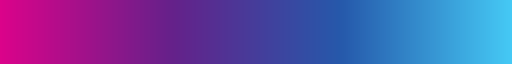

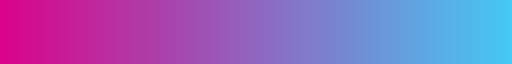

In [8]:
finomnia_palette = sns.color_palette(('#db038a',   # Pink
                                      '#66218a',   # Violet
                                      '#081c36',   # Dark Blue
                                      '#2659ab',   # blue
                                      '#45c9f5'))  # Light blue
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[1], finomnia_palette[-2], finomnia_palette[-1]])
display(finomnia_cmap)
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[-1]])
display(finomnia_cmap)


In [9]:
# Get ORIGINAL DATA
data_path = base_dir / 'data' / constants.RAW_DATA_FILE_NAME
data = pd.read_csv(data_path)
#data = data[['id', 'report_text']]
data.sort_values(by='id', inplace=True, ignore_index=True)


# delete column "posizione" as it is obsolete, renaming "posizione_multiple" in "posizione"
data.drop(columns=['posizione'], inplace=True)
data.rename(columns={'posizione_multiple': 'posizione'}, inplace=True)

sedi_linfonodi = []
for s1, s2 in zip(data.sedi_locoregionali, data.sedi_non_locoregionali):
    sedi_linfonodi.append(str(ast.literal_eval(s1) + ast.literal_eval(s2)))
data['sedi_linfonodi'] = sedi_linfonodi
print(f'Nuova colonna "sedi_linfonodi" creata\n{data.shape = }')

#####################
# Columns aggregation
#####################
# Dettagli infiltrazione organi
infiltrazione_organi_dettagli_new = []
for s in data.infiltrazione_organi_dettagli.fillna(constants.NAN_VALUE):
    dettagli = []
    if s == constants.NAN_VALUE:
        infiltrazione_organi_dettagli_new.append(str(dettagli))
    else:
        if s.strip() == '[object Object]':
            infiltrazione_organi_dettagli_new.append(str(dettagli))
            continue 
        d = ast.literal_eval(s)
        if constants.InfiltrazioneOrganiDettagli.PAVIMENTO_PELVICO.value in d:
            dettagli.append(constants.InfiltrazioneOrganiDettagli.PAVIMENTO_PELVICO.value)
        if ('altro' in d) or ('utero' in d) or ('sacro' in d):
            dettagli.append(constants.InfiltrazioneOrganiDettagli.ALTRO.value)
        infiltrazione_organi_dettagli_new.append(str(dettagli))
data.loc[:, 'infiltrazione_organi_dettagli'] = infiltrazione_organi_dettagli_new


data.set_index('id', inplace=True)
print(f'{data.shape = }')

Nuova colonna "sedi_linfonodi" creata
data.shape = (343, 45)
data.shape = (343, 44)


In [10]:
greens =    sns.color_palette('Greens', 10)
blues =     sns.color_palette('Blues', 10)
oranges =   sns.color_palette('Oranges', 10)
reds =      sns.color_palette('Reds', 10)
purples =   sns.color_palette('Purples', 10)
greys =     sns.color_palette('Greys', 10)

In [11]:

mistral_train = load_results_data("results_TRAIN_mistral_large_3.jsonl", base_dir/'data'/'inference', model_type)
mistral = load_results_data("results_mistral_large_3.jsonl", base_dir/'data'/'inference', model_type)
gpt_train = load_results_data("results_TRAIN_gpt-4.1.jsonl", base_dir/'data'/'inference', model_type)
gpt = load_results_data("results_gpt-4.1.jsonl", base_dir/'data'/'inference', model_type)
opus_train = load_results_data("results_TRAIN_opus-4.6.jsonl", base_dir/'data'/'inference', model_type)
opus = load_results_data("results_opus-4.6.jsonl", base_dir/'data'/'inference', model_type)

assert len(mistral_train) == len(gpt_train) == len(opus_train)
assert len(mistral) == len(gpt) == len(opus)

mistral = mistral_train + mistral
gpt = gpt_train + gpt
opus = opus_train + opus

mistral = {
    ex['id']: {
        'actual':       ex['actual'],
        'prediction':   ex['prediction'],
        'split':        ex['split']
    }
    for ex in mistral
}
gpt = {
    ex['id']: {
        'actual':       ex['actual'],
        'prediction':   ex['prediction'],
        'split':        ex['split']
    }
    for ex in gpt
}
opus = {
    ex['id']: {
        'actual':       ex['actual'],
        'prediction':   ex['prediction'],
        'split':        ex['split']
    }
    for ex in opus
}

# Controllo
for id in mistral:
    if mistral[id]['actual'] == gpt[id]['actual'] == opus[id]['actual']:
        continue
    else:
        print(id)

results = {
    id: {
        'actual':   gpt[id]['actual'],
        'gpt':      gpt[id]['prediction'],
        'opus':     opus[id]['prediction'],
        'mistral':  mistral[id]['prediction'],
    }
    for id in gpt
}

reports = {id: data.loc[id]['report_text'] for id in gpt}
profiles = {id: data.loc[id]['profile'] for id in gpt}

In [12]:
def report_model_to_dataframe(report_model: constants.RectalCancerStagingData, name: str) -> pd.DataFrame:
    multilabel_fields = ['posizione', 'infiltrazione_organi_dettagli', 'sedi_linfonodi']    
    model_dict = report_model.model_dump(mode='json')
    
    for f in multilabel_fields:
        label_list = []
        for l, v in model_dict[f].items():
            if v == constants.Flag.SI.value:
                label_list.append(l)
        model_dict[f] = label_list
    s = pd.Series(model_dict)
    s.name = name
    return s.to_frame()

In [13]:
def original_to_df(id: int, original_data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    result = original_data.loc[id, columns].T
    result.name = 'original'
    return result.to_frame()

In [14]:
def highlight_diff(row, color: str = 'red'):
    ref = row.iloc[1]  # prima colonna come riferimento
    styles = ['', '']  # nessuno stile per la colonna di riferimento
    for val in row.iloc[2:]:  # ultime tre colonne
        if val != ref:
            styles.append(f'background-color: {color}')
        else:
            styles.append('')
    return styles

In [15]:
print(reports.keys())

dict_keys([46, 47, 51, 54, 57, 59, 66, 74, 87, 88, 92, 98, 106, 108, 111, 116, 120, 126, 129, 130, 131, 132, 140, 153, 160, 163, 165, 174, 178, 181, 184, 185, 186, 188, 190, 191, 193, 194, 195, 196, 199, 204, 207, 208, 209, 210, 214, 221, 224, 225, 227, 229, 230, 231, 232, 234, 237, 241, 242, 243, 244, 246, 248, 250, 251, 257, 258, 260, 262, 263, 270, 271, 273, 275, 276, 282, 284, 288, 290, 291, 292, 294, 295, 296, 297, 298, 300, 302, 303, 305, 306, 307, 310, 311, 312, 313, 314, 315, 316, 318, 320, 322, 323, 324, 325, 326, 329, 331, 333, 334, 335, 336, 337, 338, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 373, 374, 375, 376, 377, 379, 380, 381, 384, 386, 387, 388, 389, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 407, 409, 410, 411, 412, 413, 415, 416, 418, 419, 420, 421, 422, 53, 56, 67, 69, 75, 78, 79, 82, 97, 99, 100, 104, 109, 112, 115, 119, 125, 135, 1

In [21]:
id = 46
original = original_to_df(id, data, list(constants.RectalCancerStagingData.model_fields.keys()))
dfs = [original] + [report_model_to_dataframe(r, n) for n, r in results[id].items()]
df = pd.concat(dfs, axis=1)
print(data.loc[id].interpretazioni)
styled = df.style.apply(highlight_diff, color='red', axis=1)

nan


In [22]:
print(id, profiles[id])
pprint(reports[id], width=170)

46 GuidoImbemba
("NEL RETTO MEDIO, A CIRCA 7 CM DAL MARGINE ANALE E 2,5 CM DALLA LINEA ANO-PETTINATA, SI METTE IN EVIDENZA LESIONE NEOFORMATA VEGETANTE A LARGA BASE D'IMPIANTO, MARGINI "
 'IRREGOLARI ED APPARENTEMENTE ULCERATI, CON DIAMETRI SUL PIANO ASSIALE DI 38X15 MM ED ESTENSIONE LONGITUDINALE DI 45 MM, LOCALIZZATA IN CORRISPONDENZA DELLA PARETE '
 'POSTERO-LATERALE DI SINISTRA. LA NEOFORMAZIONE INFILTRA A TUTTO SPESSORE LA PARETE RETTALE CON INIZIALI SEGNI DI ESTENSIONE EXTRA-PARIETALE COME PER LESIONE T3A; NEL '
 "SUO TRATTO INFERIORE CONTRAE STRETTI RAPPORTI DI CONTIGUITÀ CON I FASCI CRANIALI DEL M. ELEVATORE DELL'ANO DI SINISTRA. NON RILEVABILI SEGNI DI MACROSCOPICO "
 'COINVOLGIMENTO DELLA FASCIA MESORETTALE.\r\n'
 'SI RILEVANO LINFOADENOPATIE ROTONDEGGIANTI IN SEDE MESORETTALE POSTERIORE (5 MM) LUNGO IL DECORSO DEI VASI EMORROIDARI SUPERIORI E IN SEDE PRESACRALE (DM 11 MM);ALTRA '
 'LINFOADENOPATIA IN SEDE OTTURATORIA INTERNA DESTRA (11 MM); NON VALUTABILE LA REGIONE ILIACO-O

In [23]:
print(id)
display(styled)
print(id, profiles[id])
pprint(reports[id])

46


,original,actual,gpt,opus,mistral
morfologia,solido_polipoide,solido_polipoide,solido_polipoide,solido_polipoide,solido_polipoide
ore_inizio,nan,None,None,7,None
ore_fine,nan,None,None,10,None
spessore_parietale,nan,None,15,15,38
estensione_cranio_caudale,45.000000,45,45,45,45
distanza_oai,25.000000,25,25,25,25
posizione,['medio'],['medio'],['medio'],['medio'],"['basso', 'medio']"
riflessione_peritoneale_anteriore,nan,non_valutabile,sotto,sotto,non_valutabile
infiltrazione_tessuto_adiposo,si_5mm,si_5mm,si_5mm,si_5mm,si_5mm
infiltrazione_sfinteri,no,no,no,no,no


46 GuidoImbemba
('NEL RETTO MEDIO, A CIRCA 7 CM DAL MARGINE ANALE E 2,5 CM DALLA LINEA '
 'ANO-PETTINATA, SI METTE IN EVIDENZA LESIONE NEOFORMATA VEGETANTE A LARGA '
 "BASE D'IMPIANTO, MARGINI IRREGOLARI ED APPARENTEMENTE ULCERATI, CON DIAMETRI "
 'SUL PIANO ASSIALE DI 38X15 MM ED ESTENSIONE LONGITUDINALE DI 45 MM, '
 'LOCALIZZATA IN CORRISPONDENZA DELLA PARETE POSTERO-LATERALE DI SINISTRA. LA '
 'NEOFORMAZIONE INFILTRA A TUTTO SPESSORE LA PARETE RETTALE CON INIZIALI SEGNI '
 'DI ESTENSIONE EXTRA-PARIETALE COME PER LESIONE T3A; NEL SUO TRATTO INFERIORE '
 'CONTRAE STRETTI RAPPORTI DI CONTIGUITÀ CON I FASCI CRANIALI DEL M. ELEVATORE '
 "DELL'ANO DI SINISTRA. NON RILEVABILI SEGNI DI MACROSCOPICO COINVOLGIMENTO "
 'DELLA FASCIA MESORETTALE.\r\n'
 'SI RILEVANO LINFOADENOPATIE ROTONDEGGIANTI IN SEDE MESORETTALE POSTERIORE (5 '
 'MM) LUNGO IL DECORSO DEI VASI EMORROIDARI SUPERIORI E IN SEDE PRESACRALE (DM '
 '11 MM);ALTRA LINFOADENOPATIA IN SEDE OTTURATORIA INTERNA DESTRA (11 MM); NON '
 'VA

In [19]:
"ispessimento" in reports[id]

False

In [20]:
data[data['discrepanze_rilevate'] != "['nessuna']"][['discrepanze_rilevate', 'interpretazioni']]

,discrepanze_rilevate,interpretazioni
id,,
135,"['n_classification', 'linfonodi_sospetti']",NaN
183,"['n_classification', 'depositi_tumorali']",NaN
184,"['n_classification', 'depositi_tumorali']",NaN
195,"['n_classification', 'linfonodi_sospetti']","- Mettiamo classe piu bassa N2a, ma numero non..."
202,"['n_classification', 'linfonodi_sospetti']",non sono specificati bene il linfonodi… sono d...
211,"['n_classification', 'linfonodi_sospetti']",non chiaramente specificata l'invasione mesore...
214,"['n_classification', 'linfonodi_sospetti']",non chiara l'invasione del mesoretto.\r\n\r\n-...
361,"['n_classification', 'linfonodi_sospetti']",NaN
411,"['n_classification', 'linfonodi_sospetti']",da referto non chiaro quali e quanti linfonodi...
